## Step 1 — Install & Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, shutil, glob, warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# GPU check
gpus = tf.config.list_physical_devices('GPU')
assert gpus, 'No GPU found! Change runtime to T4.'
tf.config.experimental.set_memory_growth(gpus[0], True)
print(f'✓ GPU: {gpus[0].name}')
print(f'✓ TF : {tf.__version__}')

✓ GPU: /physical_device:GPU:0
✓ TF : 2.19.0


## Step 2 — Download Data (Kaggle)

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("robiulhasanjisan/leaf-vs-non-leaf-images")

print("Path to dataset files:", path)

100%|██████████| 2.25G/2.25G [02:18<00:00, 17.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/robiulhasanjisan/leaf-vs-non-leaf-images/versions/1


In [3]:
!ls /root/.cache/kagglehub/datasets/robiulhasanjisan/leaf-vs-non-leaf-images/versions/1

leaf  non_leaf


In [4]:
PLANT_DIR    = Path('/root/.cache/kagglehub/datasets/robiulhasanjisan/leaf-vs-non-leaf-images/versions/1/leaf')
NONPLANT_DIR = Path('/root/.cache/kagglehub/datasets/robiulhasanjisan/leaf-vs-non-leaf-images/versions/1/non_leaf')

## Step 3 — Split Data

In [5]:
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def collect(folder, label):
    rows = []
    for f in Path(folder).iterdir():
        if f.suffix.lower() in VALID_EXTS and f.stat().st_size > 1000:
            rows.append({'path': str(f), 'label': label, 'y': int(label == 'plant')})
    return rows

df = pd.DataFrame(collect(PLANT_DIR, 'plant') + collect(NONPLANT_DIR, 'non_plant'))
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Total : {len(df):,}')
print(df['label'].value_counts().to_string())

train_df, temp_df = train_test_split(df, train_size=0.8, stratify=df['label'], random_state=42)
val_df,  test_df  = train_test_split(temp_df, train_size=0.5, stratify=temp_df['label'], random_state=42)

print(f'\nTrain : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}')

Total : 13,000
label
plant        6500
non_plant    6500

Train : 10,400  |  Val : 1,300  |  Test : 1,300


## Step 4 — Data Pipeline

In [6]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

def load_and_preprocess(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3, try_recover_truncated=True)
    img = tf.image.resize(img, IMG_SIZE)
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)
    img = preprocess_input(img)
    return img, tf.cast(label, tf.float32)

def make_dataset(df, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((df['path'].values, df['y'].values))
    if augment:
        ds = ds.shuffle(10000)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l, augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.apply(tf.data.experimental.ignore_errors())
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, augment=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

for imgs, lbls in train_ds.take(1):
    print(f'✓ Batch: images={imgs.shape}  labels={lbls.numpy()[:6]}')

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


✓ Batch: images=(32, 224, 224, 3)  labels=[0. 0. 1. 1. 0. 1.]


## Step 5 — Build Model

In [7]:
backbone = MobileNetV3Large(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
backbone.trainable = False  # freeze for phase 1

x = GlobalAveragePooling2D()(backbone.output)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid', dtype='float32')(x)  # plant=1, non_plant=0

model = Model(backbone.input, output)

model.compile(
    optimizer=Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print(f'Total params    : {model.count_params():,}')
print(f'Trainable params: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}')

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total params    : 3,119,489
Trainable params: 123,137


## Step 6 — Train

In [8]:
os.makedirs('/content/checkpoints', exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint('/content/checkpoints/plant_or_not.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
]

# Phase 1 — frozen backbone (fast, ~5 min)
print('── Phase 1: head only ──')
model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

# Phase 2 — unfreeze top layers (fine-tune)
print('\n── Phase 2: fine-tune top 30 layers ──')
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

── Phase 1: head only ──
Epoch 1/10
    325/Unknown 106s 252ms/step - accuracy: 0.9613 - auc: 0.9896 - loss: 0.0825
Epoch 1: val_accuracy improved from None to 0.99615, saving model to /content/checkpoints/plant_or_not.keras

Epoch 1: finished saving model to /content/checkpoints/plant_or_not.keras
325/325 ━━━━━━━━━━━━━━━━━━━━ 133s 335ms/step - accuracy: 0.9862 - auc: 0.9990 - loss: 0.0361 - val_accuracy: 0.9962 - val_auc: 1.0000 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 2/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9970 - auc: 0.9998 - loss: 0.0109
Epoch 2: val_accuracy improved from 0.99615 to 0.99923, saving model to /content/checkpoints/plant_or_not.keras

Epoch 2: finished saving model to /content/checkpoints/plant_or_not.keras
325/325 ━━━━━━━━━━━━━━━━━━━━ 77s 237ms/step - accuracy: 0.9971 - auc: 0.9998 - loss: 0.0098 - val_accuracy: 0.9992 - val_auc: 1.0000 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 3/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - ac

## Step 7 — Evaluate

In [9]:
y_true, y_pred = [], []
for imgs, lbls in test_ds:
    probs = model.predict(imgs, verbose=0).flatten()
    y_pred.extend((probs >= 0.5).astype(int))
    y_true.extend(lbls.numpy().astype(int))

print(classification_report(y_true, y_pred, target_names=['non_plant', 'plant']))

              precision    recall  f1-score   support

   non_plant       1.00      1.00      1.00       650
       plant       1.00      1.00      1.00       650

    accuracy                           1.00      1300
   macro avg       1.00      1.00      1.00      1300
weighted avg       1.00      1.00      1.00      1300



### Confusion Matrix

<Figure size 800x600 with 0 Axes>

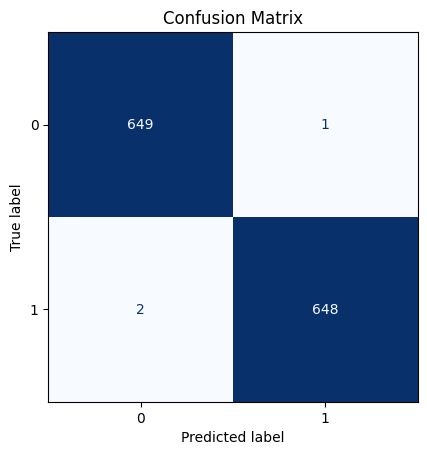

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, values_format='.0f', cmap=plt.cm.Blues, colorbar=False)
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

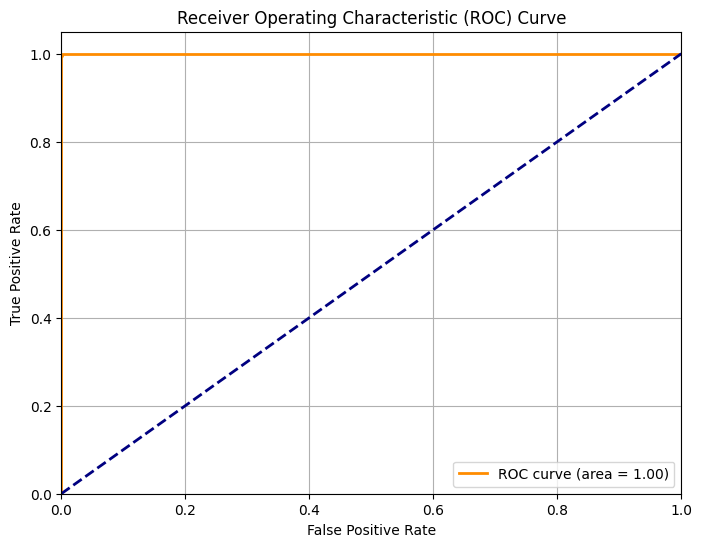

In [15]:
from sklearn.metrics import roc_curve, auc

# Get probabilities for the test set
all_probs = []
all_true = []
for imgs, lbls in test_ds:
    probs_batch = model.predict(imgs, verbose=0).flatten()
    all_probs.extend(probs_batch)
    all_true.extend(lbls.numpy())

# Convert to numpy arrays
all_probs = np.array(all_probs)
all_true = np.array(all_true)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Step 8 — Predict on Any Image

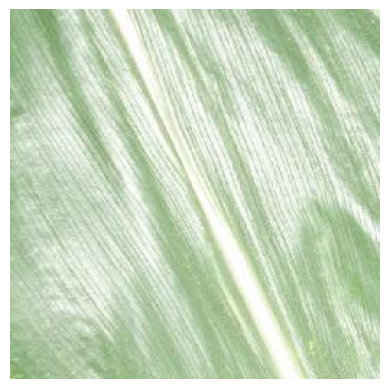

→ plant  (confidence: 100.0%)


'plant'

In [11]:
def predict(image_path: str) -> str:
    img = tf.image.decode_jpeg(tf.io.read_file(image_path), channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(tf.cast(img, tf.float32))
    prob = float(model.predict(tf.expand_dims(img, 0), verbose=0)[0][0])
    label = 'plant' if prob >= 0.5 else 'not plant'
    print(f'→ {label}  (confidence: {max(prob, 1-prob)*100:.1f}%)')
    return label

# Test on one image from the test set
sample = test_df['path'].iloc[0]
plt.imshow(plt.imread(sample))
plt.axis('off')
plt.show()
predict(sample)

## Step 9 — Save Model

In [12]:
model.save('/content/plant_or_not_final.keras')
print('✓ Model saved → /content/plant_or_not_final.keras')

# Uncomment to save to Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# shutil.copy('/content/plant_or_not_final.keras', '/content/drive/MyDrive/plant_or_not_final.keras')
# print('✓ Copied to Drive')

✓ Model saved → /content/plant_or_not_final.keras
